# Import Libraries 

In [222]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [231]:
import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter
from features import engineering

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)
importlib.reload(engineering)

<module 'features.engineering' from '/home/luke/projects/agriculture-analysis/src/features/engineering.py'>

# Prepare DataFrames

In [209]:
region = utils.get_region()
i_date = "2021-01-01"
f_date = "2024-12-31"

In [ ]:

    print(f"Loading Sentinel-2 dataset for periods {i_date} to {f_date}...")
    s2_clouded = load_S2.get_s2_data(region, i_date, f_date)

    print(f"Loading ERA5 Land data for periods {i_date} to {f_date}...")
    era5_data = load_ERA5.get_era5_data(region, i_date, f_date)

    print(f"Loading CHIRPS Climate Data for periods {i_date} to {f_date}...")
    chirps_data = load_CHIRPS.get_chirps_data(region, i_date, f_date)

    s2_clear_sky = s2_clouded.map(load_S2.s2_clear_sky)

    reducer_fn = utils.create_reducer(region, scale=10)
    ndvi_df = indices.get_index_df(s2_clear_sky, indices.NDVI, reducer_fn)
    ndre_df = indices.get_index_df(s2_clear_sky, indices.NDRE, reducer_fn)
    ndwi_df = indices.get_index_df(s2_clear_sky, indices.NDWI, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=20)
    slvw_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "water")
    slt_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "temp")
    temp_2m_df = load_ERA5.get_temp_2m_df(era5_data, reducer_fn)
    ssrd_df = load_ERA5.get_ssrd(era5_data, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=5566)
    perc_df = load_CHIRPS.get_precipitation_df(chirps_data, reducer_fn)

    grouped = indices.apply_groupby_date(ndwi_df, ndvi_df, ndre_df)
    ndwi_df_grouped = grouped[0]
    ndvi_df_grouped = grouped[1]
    ndre_df_grouped = grouped[2]

    master_df = utils.merge_with_master(
        ndvi_df_grouped,
        ndwi_df_grouped,
        ndre_df_grouped,
        slvw_df,
        slt_df,
        temp_2m_df,
        ssrd_df,
        perc_df,
    )
    print("Done!")



In [94]:
non_spectral_df = utils.merge_with_master(slvw_df, slt_df, temp_2m_df, ssrd_df, perc_df)
non_spectral_df.to_csv("non_spectral_df.csv")

In [95]:
spectral_df = utils.merge_with_master(ndvi_df, ndwi_df, ndre_df)
spectral_df.to_csv("spectral_df.csv")

In [91]:
grouped = indices.apply_groupby_date(ndwi_df, ndvi_df, ndre_df)
ndwi_df_grouped = grouped[0]
ndvi_df_grouped = grouped[1]
ndre_df_grouped = grouped[2]


In [96]:
grouped_spectral_df = utils.merge_with_master(ndvi_df_grouped, ndwi_df_grouped, ndre_df_grouped)
grouped_spectral_df.to_csv("grouped_spectral_df.csv")

In [243]:
non_spectral_df = pd.read_csv("non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

In [244]:
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,surface_solar_radiation_downwards_sum,precipitation
0,2021-02-10,0.673053,0.028794,0.440118,0.042311,0.453268,0.040651,0.462551,0.448877,0.466825,0.300550,294.069889,293.548100,292.099834,291.449413,291.738612,2.222716e+07,27.658445
1,2021-02-20,0.654526,0.033826,0.382090,0.038691,0.453253,0.040155,0.358619,0.392014,0.434314,0.305685,293.022377,293.184996,292.514029,291.599089,292.496838,2.991418e+07,0.000000
2,2021-03-02,0.594535,0.014670,0.368082,0.021772,0.398210,0.022341,0.404106,0.425275,0.420446,0.307468,291.241525,291.304370,291.940702,291.704808,289.210858,2.428342e+07,0.000000
3,2021-03-07,0.626770,0.029061,0.335441,0.029934,0.439704,0.029284,0.342668,0.378511,0.408774,0.307995,291.952316,292.235655,292.064194,291.723281,291.937318,2.818333e+07,0.000000
4,2021-03-12,0.550777,0.035823,0.307853,0.018624,0.353930,0.034134,0.285966,0.337627,0.394000,0.308202,293.938185,293.305163,292.253616,291.752717,292.743804,2.389983e+07,0.185567


# Time-series visualisation

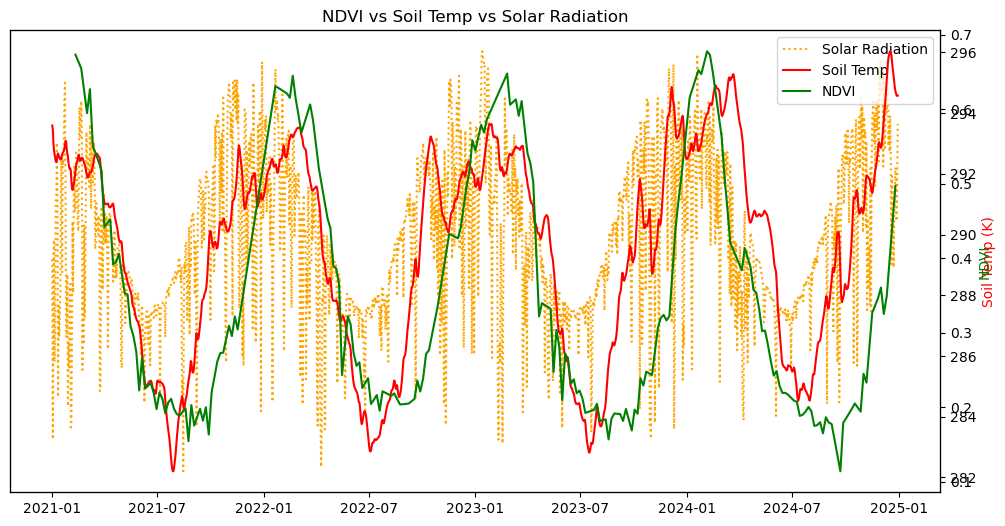

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(non_spectral_df["Timestamp"], non_spectral_df["surface_solar_radiation_downwards_sum"], color="orange", linestyle=":", label="Solar Radiation")
ax1.get_yaxis().set_visible(False)

ax2 = ax1.twinx()
ax2.plot(non_spectral_df["Timestamp"], non_spectral_df["soil_temperature_level_3"], color="red", label="Soil Temp")
ax2.set_ylabel("Soil Temp (K)", color="red")

ax3 = ax1.twinx()
ax3.plot(grouped_spectral_df["Timestamp"], grouped_spectral_df["NDVI_mean"], color="green", label="NDVI")
ax3.set_ylabel("NDVI", color="green")

lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
plt.title("NDVI vs Soil Temp vs Solar Radiation")
plt.show()


## NDVI Mean per DOY

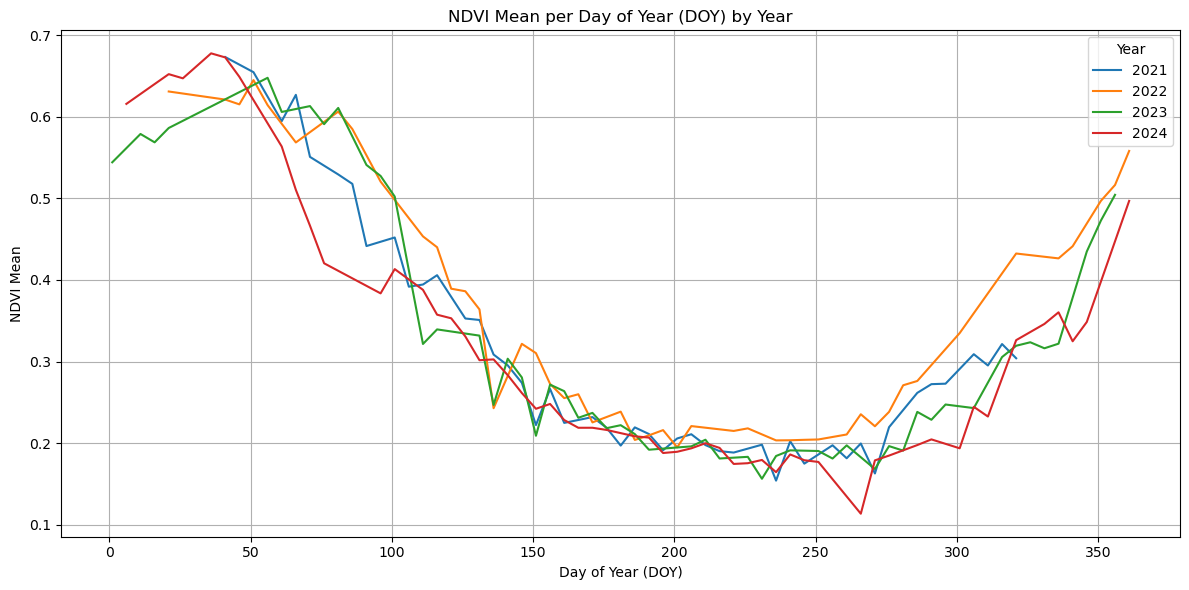

In [213]:
doy_df = grouped_spectral_df.copy()
doy_df["DOY"] = grouped_spectral_df["Timestamp"].dt.dayofyear
doy_df["Year"]=pd.DatetimeIndex(grouped_spectral_df["Timestamp"]).year
index_plotter.plot_index_doy_barchart(doy_df, indices.NDVI)

# Features

The point of this project is to create a Machine Learning model that can accurately forecast NDVI 14 to 21 days ahead of time. Because of this, we need to start by finding environmental variables that correlate with the known NDVI values in `spectral_df`, but with the spectral index shifted into the future by 21 days.

In [221]:
feature_df = grouped_spectral_df[["Timestamp", "NDVI_mean"]].copy()
feature_df["NDVI_target"] = grouped_spectral_df["NDVI_mean"].shift(-21)
feature_df.head()

,Timestamp,NDVI_mean,NDVI_target
0,2021-02-10,0.673053,0.219043
1,2021-02-20,0.654526,0.197174
2,2021-03-02,0.594535,0.219492
3,2021-03-07,0.626770,0.211328
4,2021-03-12,0.550777,0.191533


## Non-Spectral Variables

In [250]:
non_spectral_df.head()

,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,surface_solar_radiation_downwards_sum,precipitation
0,2021-01-01,0.464211,0.450695,0.386216,0.268048,293.981469,294.836560,293.594721,290.617315,290.482622,1.817586e+07,17.815686
1,2021-01-02,0.475037,0.480518,0.400676,0.268137,288.502695,291.420716,293.440151,290.661477,285.034479,4.846494e+06,19.755076
2,2021-01-03,0.465711,0.474780,0.423098,0.268330,291.363762,290.903178,293.003565,290.700283,290.137581,1.847128e+07,0.000000
3,2021-01-04,0.459716,0.473242,0.425570,0.268588,292.646723,292.263110,292.764687,290.733492,290.954968,1.964366e+07,0.000000
4,2021-01-05,0.474094,0.482023,0.433275,0.268882,291.727492,292.221338,292.646230,290.763769,290.405214,1.058660e+07,11.698313


### Lagging Non-Spectral Variables

One of the most obvious assumptions we can make for predicting NDVI is that crops typically have a **lagged** response. This means that rainfaill on the _current_ day will only have a noticable effect on vegetation a few days into the _future_ (if every other aspect of the plant is in order, that is.) 

We will start our approach to lagging by using a simple period of $p\ \epsilon\ \{0, 3, 7, 14, 21\}$. Naturally what this means is the feature in question ($x$) will be **shifted** by a period of $p$ into the _past_.

In [248]:
periods = [0, 3, 7, 14, 21]
columns = non_spectral_df.columns
ns_lag = engineering.lag_col(non_spectral_df, columns, periods)
ns_lag.head()

,Timestamp,volumetric_soil_water_layer_1_lag_0,volumetric_soil_water_layer_1_lag_3,volumetric_soil_water_layer_1_lag_7,volumetric_soil_water_layer_1_lag_14,volumetric_soil_water_layer_1_lag_21,volumetric_soil_water_layer_2_lag_0,volumetric_soil_water_layer_2_lag_3,volumetric_soil_water_layer_2_lag_7,volumetric_soil_water_layer_2_lag_14,...,surface_solar_radiation_downwards_sum_lag_0,surface_solar_radiation_downwards_sum_lag_3,surface_solar_radiation_downwards_sum_lag_7,surface_solar_radiation_downwards_sum_lag_14,surface_solar_radiation_downwards_sum_lag_21,precipitation_lag_0,precipitation_lag_3,precipitation_lag_7,precipitation_lag_14,precipitation_lag_21
0,2021-01-01,0.464211,NaN,NaN,NaN,NaN,0.450695,NaN,NaN,NaN,...,1.817586e+07,NaN,NaN,NaN,NaN,17.815686,NaN,NaN,NaN,NaN
1,2021-01-02,0.475037,NaN,NaN,NaN,NaN,0.480518,NaN,NaN,NaN,...,4.846494e+06,NaN,NaN,NaN,NaN,19.755076,NaN,NaN,NaN,NaN
2,2021-01-03,0.465711,NaN,NaN,NaN,NaN,0.474780,NaN,NaN,NaN,...,1.847128e+07,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
3,2021-01-04,0.459716,0.464211,NaN,NaN,NaN,0.473242,0.450695,NaN,NaN,...,1.964366e+07,1.817586e+07,NaN,NaN,NaN,0.000000,17.815686,NaN,NaN,NaN
4,2021-01-05,0.474094,0.475037,NaN,NaN,NaN,0.482023,0.480518,NaN,NaN,...,1.058660e+07,4.846494e+06,NaN,NaN,NaN,11.698313,19.755076,NaN,NaN,NaN


Of course, the shifts do cause null values to be present in the dataset, but we will focus on that issue later down the line.

### Rolling non-spectral variables

Next, another obvious assumption we can make is that vegetation is effected by **prolonged** exposure to some sort of environmental factor. For example, week-long droughts will have an adverse effect on the health and greenery (and therefore the NDVI) of the region in question, if not properly irrigated.

Rolling statistics account for this behaviour in a multitude of ways. First, we can find the **average** value of some variable over some period. This is simply a way to ask "How did the vegetation react to the $p$-day long exposure of feature $x$?". Similar values can be calculated for the **sum-total**, **standard deviation** and **median**. 

We will again be using $p\ \epsilon\ \{0, 3, 7, 14, 21\}$.

In [254]:
periods = [3, 7, 14, 21]
ns_rolling = engineering.add_rolling_statistics(non_spectral_df, periods)

/home/luke/projects/agriculture-analysis/src/features/engineering.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f"{c}_{window}D_median"] = (
/home/luke/projects/agriculture-analysis/src/features/engineering.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f"{c}_{window}D_mean"] = df[c].rolling(window=window).mean()
/home/luke/projects/agriculture-analysis/src/features/engineering.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

In [255]:
ns_rolling.tail()

,Timestamp,volumetric_soil_water_layer_1_3D_mean,volumetric_soil_water_layer_1_3D_std,volumetric_soil_water_layer_1_3D_sum,volumetric_soil_water_layer_1_3D_median,volumetric_soil_water_layer_1_7D_mean,volumetric_soil_water_layer_1_7D_std,volumetric_soil_water_layer_1_7D_sum,volumetric_soil_water_layer_1_7D_median,volumetric_soil_water_layer_1_14D_mean,...,precipitation_7D_sum,precipitation_7D_median,precipitation_14D_mean,precipitation_14D_std,precipitation_14D_sum,precipitation_14D_median,precipitation_21D_mean,precipitation_21D_std,precipitation_21D_sum,precipitation_21D_median
1455,2024-12-26,0.406554,0.016252,1.219663,0.405201,0.415457,0.014357,2.908201,0.416676,0.378020,...,10.445830,0.0,4.914033,6.412863,68.796456,1.423826,4.072360,5.548138,85.519553,2.038970
1456,2024-12-27,0.397806,0.007109,1.193417,0.397196,0.409804,0.012196,2.868630,0.415756,0.387813,...,15.259949,0.0,5.257898,6.256255,73.610575,3.245805,4.301603,5.470371,90.333672,2.235538
1457,2024-12-28,0.413925,0.034461,1.241774,0.397196,0.415073,0.020677,2.905511,0.415756,0.401566,...,12.741425,0.0,4.985501,6.401572,69.797017,1.423826,4.305402,5.467261,90.413437,2.235538
1458,2024-12-29,0.428790,0.028794,1.286369,0.435616,0.417910,0.022100,2.925371,0.419339,0.413454,...,4.893883,0.0,4.967689,6.416094,69.547652,1.339026,3.918569,5.470993,82.289952,2.038970
1459,2024-12-30,0.430559,0.025900,1.291677,0.435616,0.415505,0.022823,2.908536,0.405201,0.419102,...,4.915255,0.0,3.731690,5.445730,52.243658,0.050568,3.729366,5.536542,78.316683,0.330465


### Visualisation

In [269]:
df = utils.merge_with_master(feature_df, ns_lag, ns_rolling)
df.head()

,Timestamp,NDVI_mean,NDVI_target,Year,Month,Day,DOY,DOY_sin,DOY_cos,volumetric_soil_water_layer_1_lag_0,...,precipitation_7D_sum,precipitation_7D_median,precipitation_14D_mean,precipitation_14D_std,precipitation_14D_sum,precipitation_14D_median,precipitation_21D_mean,precipitation_21D_std,precipitation_21D_sum,precipitation_21D_median
0,2021-02-10,0.673053,0.219043,2021,2,10,41,0.648262,0.761418,0.462551,...,76.736754,6.958094,7.398906,8.682627,103.584688,5.530965,5.305433,7.765173,111.414095,0.995626
1,2021-02-20,0.654526,0.197174,2021,2,20,51,0.769031,0.639212,0.358619,...,22.992151,0.000000,5.782008,10.259012,80.948110,0.223750,5.632927,8.724714,118.291460,0.514173
2,2021-03-02,0.594535,0.219492,2021,3,2,61,0.867099,0.498137,0.404106,...,1.721757,0.000000,0.141700,0.339288,1.983797,0.000000,2.527709,7.451760,53.081894,0.000000
3,2021-03-07,0.626770,0.211328,2021,3,7,66,0.906686,0.421806,0.342668,...,2.159944,0.000000,0.295982,0.471497,4.143742,0.028864,1.236710,4.735101,25.970919,0.000000
4,2021-03-12,0.550777,0.191533,2021,3,12,71,0.939570,0.342357,0.285966,...,2.161183,0.000000,0.245281,0.407323,3.433941,0.000000,0.238235,0.413087,5.002933,0.000000


In [270]:
corrs = df.corr(method='spearman')['NDVI_target'].drop('NDVI_target')
corrs_abs = corrs.abs().sort_values(ascending=False)
top_features = corrs_abs.head(20).index.tolist()

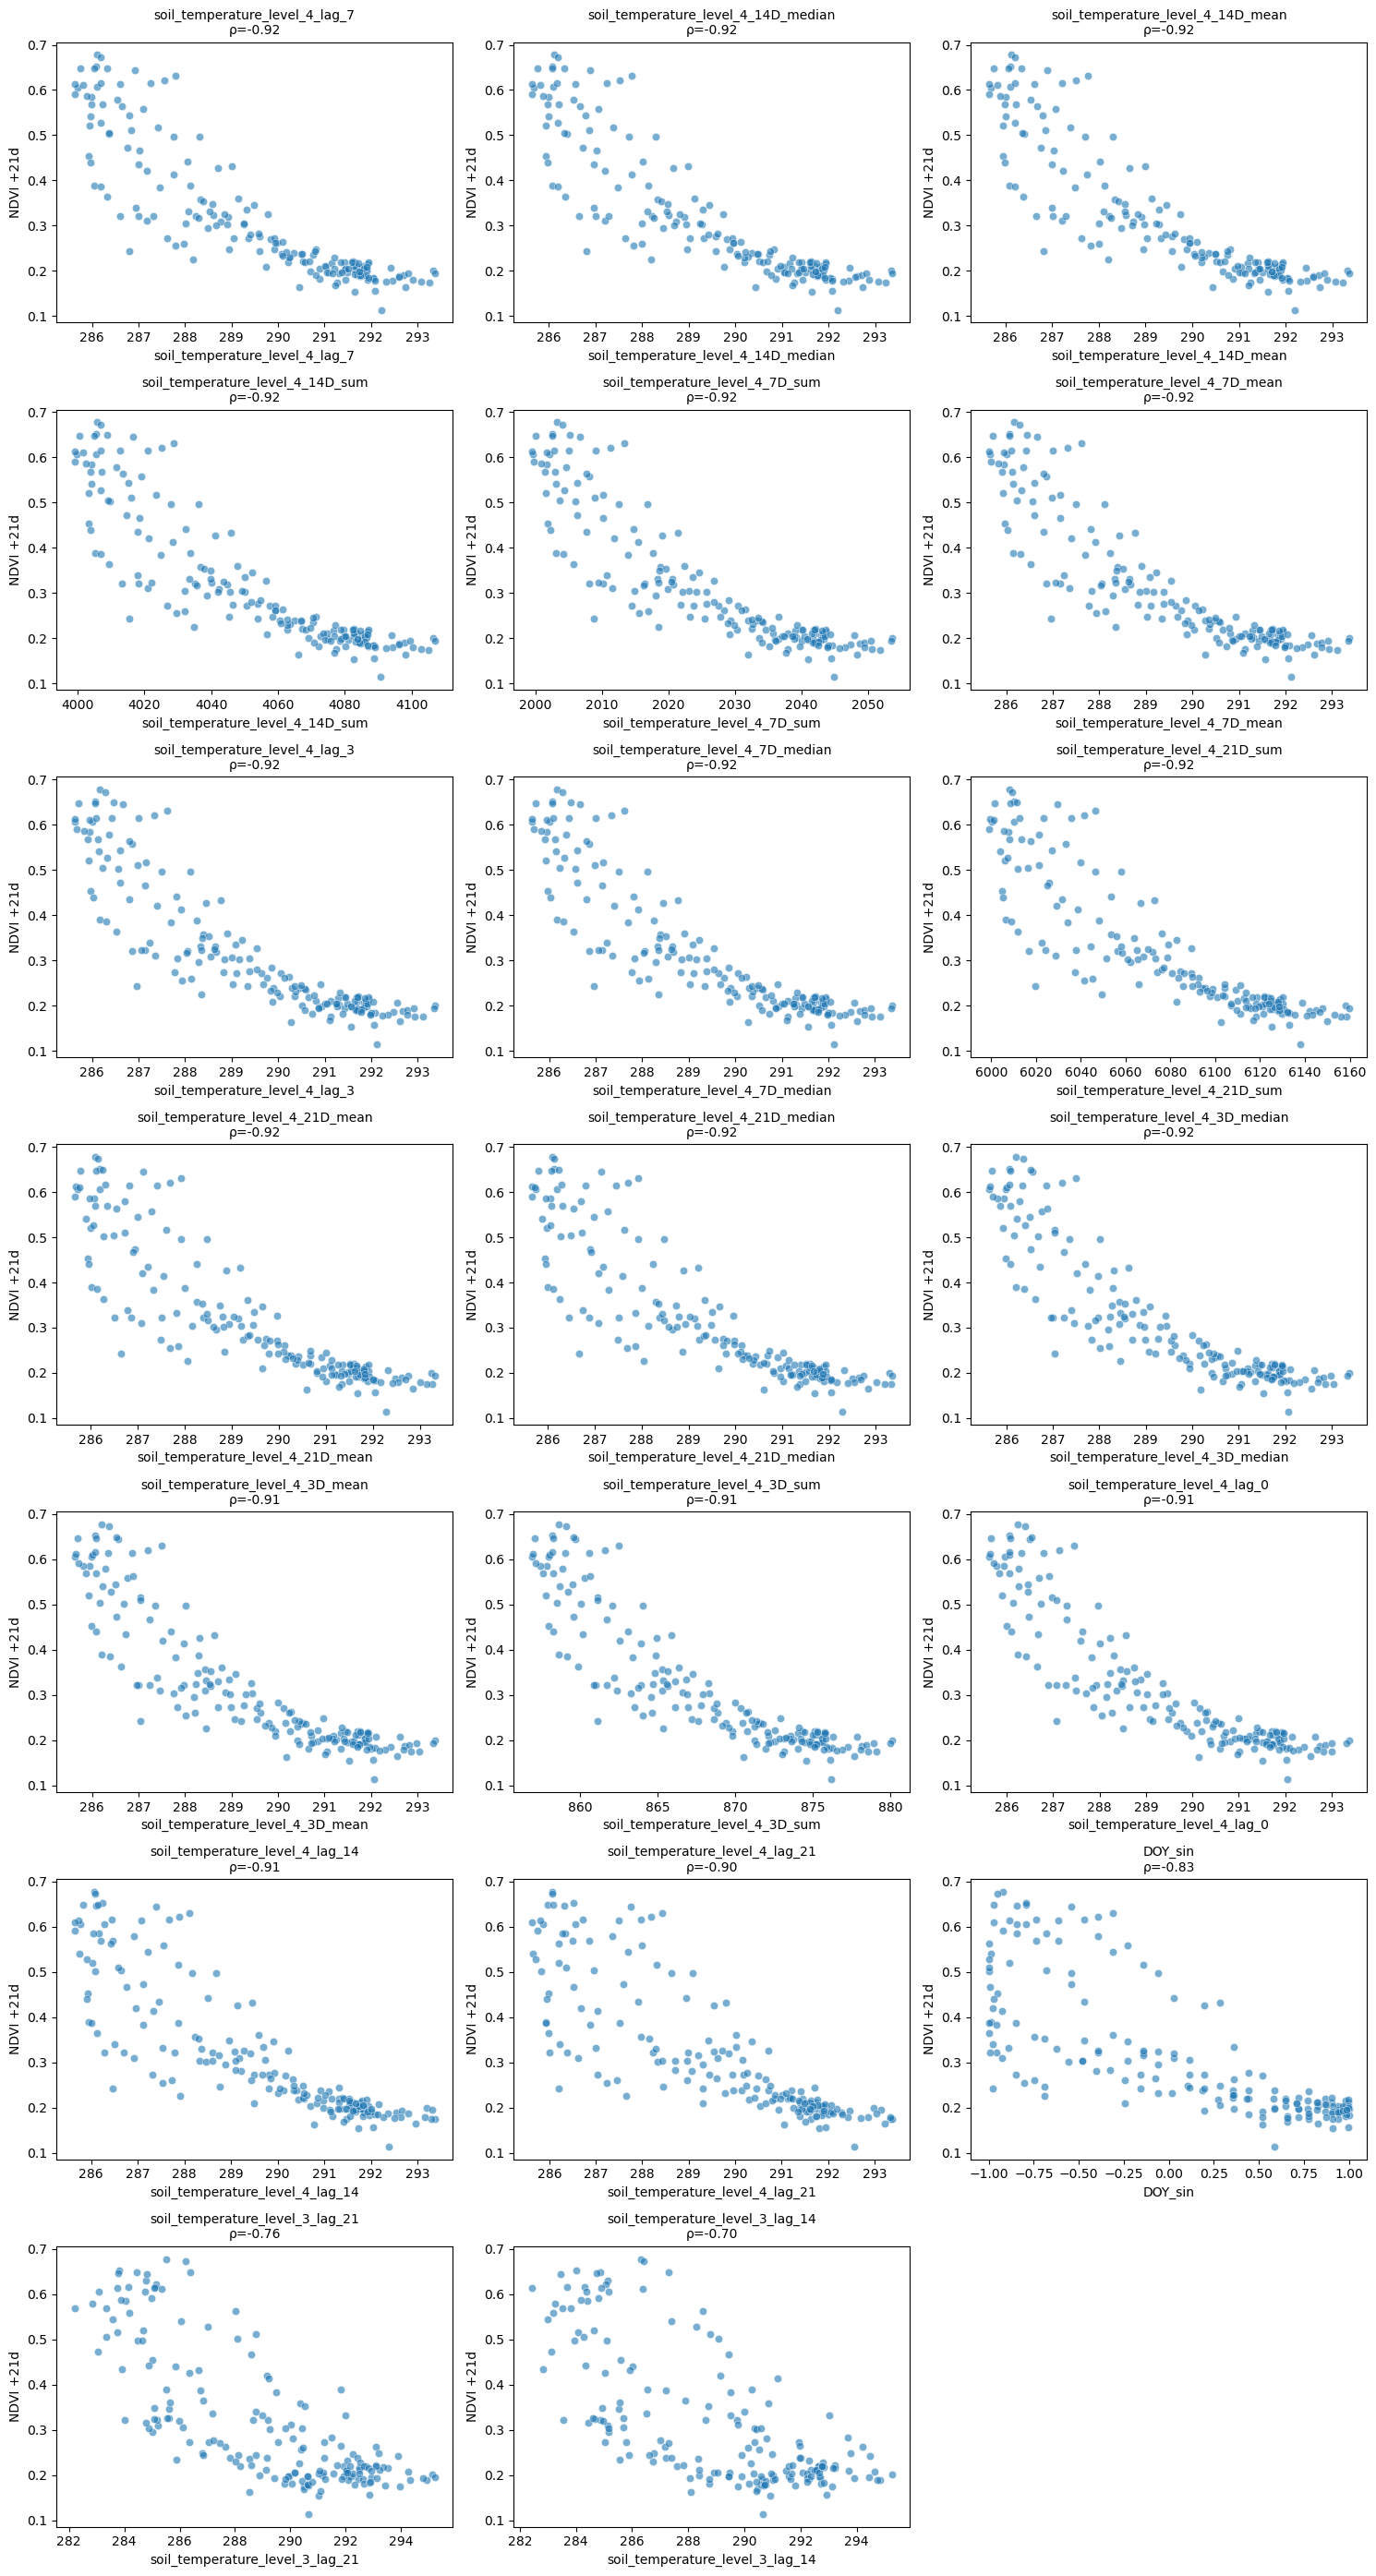

In [271]:
n = len(top_features)
cols = 3
rows = -(-n // cols)  # ceiling division

plt.figure(figsize=(5 * cols, 4 * rows))

for i, feature in enumerate(top_features):
    plt.subplot(rows, cols, i + 1)
    sns.scatterplot(x=df[feature], y=df['NDVI_target'], alpha=0.6)
    plt.title(f"{feature}\nρ={corrs[feature]:.2f}", fontsize=10)
    plt.xlabel(feature)
    plt.ylabel("NDVI +21d")

plt.tight_layout()
plt.show()

In [287]:
test_df = non_spectral_df[["Timestamp", "surface_solar_radiation_downwards_sum"]]
periods = [0, 3, 7, 14, 21]
lag_perc = engineering.lag_col(test_df, test_df.columns, periods)
roll_perc = engineering.add_rolling_statistics(test_df, periods)

In [288]:
df = utils.merge_with_master(feature_df, lag_perc, roll_perc)
df.head()

,Timestamp,NDVI_mean,NDVI_target,Year,Month,Day,DOY,DOY_sin,DOY_cos,surface_solar_radiation_downwards_sum_lag_0,...,surface_solar_radiation_downwards_sum_7D_sum,surface_solar_radiation_downwards_sum_7D_median,surface_solar_radiation_downwards_sum_14D_mean,surface_solar_radiation_downwards_sum_14D_std,surface_solar_radiation_downwards_sum_14D_sum,surface_solar_radiation_downwards_sum_14D_median,surface_solar_radiation_downwards_sum_21D_mean,surface_solar_radiation_downwards_sum_21D_std,surface_solar_radiation_downwards_sum_21D_sum,surface_solar_radiation_downwards_sum_21D_median
0,2021-02-10,0.673053,0.219043,2021,2,10,41,0.648262,0.761418,2.222716e+07,...,1.398382e+08,2.170934e+07,1.520001e+07,6.539698e+06,2.128002e+08,1.540692e+07,1.741083e+07,7.566597e+06,3.656275e+08,1.635632e+07
1,2021-02-20,0.654526,0.197174,2021,2,20,51,0.769031,0.639212,2.991418e+07,...,1.823938e+08,2.711019e+07,2.492549e+07,3.222223e+06,3.489568e+08,2.511269e+07,2.098975e+07,6.975834e+06,4.407848e+08,2.222716e+07
2,2021-03-02,0.594535,0.219492,2021,3,2,61,0.867099,0.498137,2.428342e+07,...,1.395370e+08,2.075096e+07,2.212064e+07,7.079600e+06,3.096890e+08,2.387450e+07,2.256148e+07,5.891694e+06,4.737910e+08,2.387891e+07
3,2021-03-07,0.626770,0.211328,2021,3,7,66,0.906686,0.421806,2.818333e+07,...,1.792353e+08,2.515139e+07,2.090113e+07,5.982037e+06,2.926158e+08,2.350938e+07,2.300024e+07,5.997660e+06,4.830050e+08,2.477762e+07
4,2021-03-12,0.550777,0.191533,2021,3,12,71,0.939570,0.342357,2.389983e+07,...,1.770095e+08,2.522829e+07,2.468404e+07,2.713087e+06,3.455766e+08,2.496450e+07,2.269170e+07,5.685176e+06,4.765258e+08,2.428342e+07


In [289]:
corrs = df.corr(method='spearman')['NDVI_target'].drop('NDVI_target')
corrs_abs = corrs.abs().sort_values(ascending=False)
top_features = corrs_abs.head(20).index.tolist()

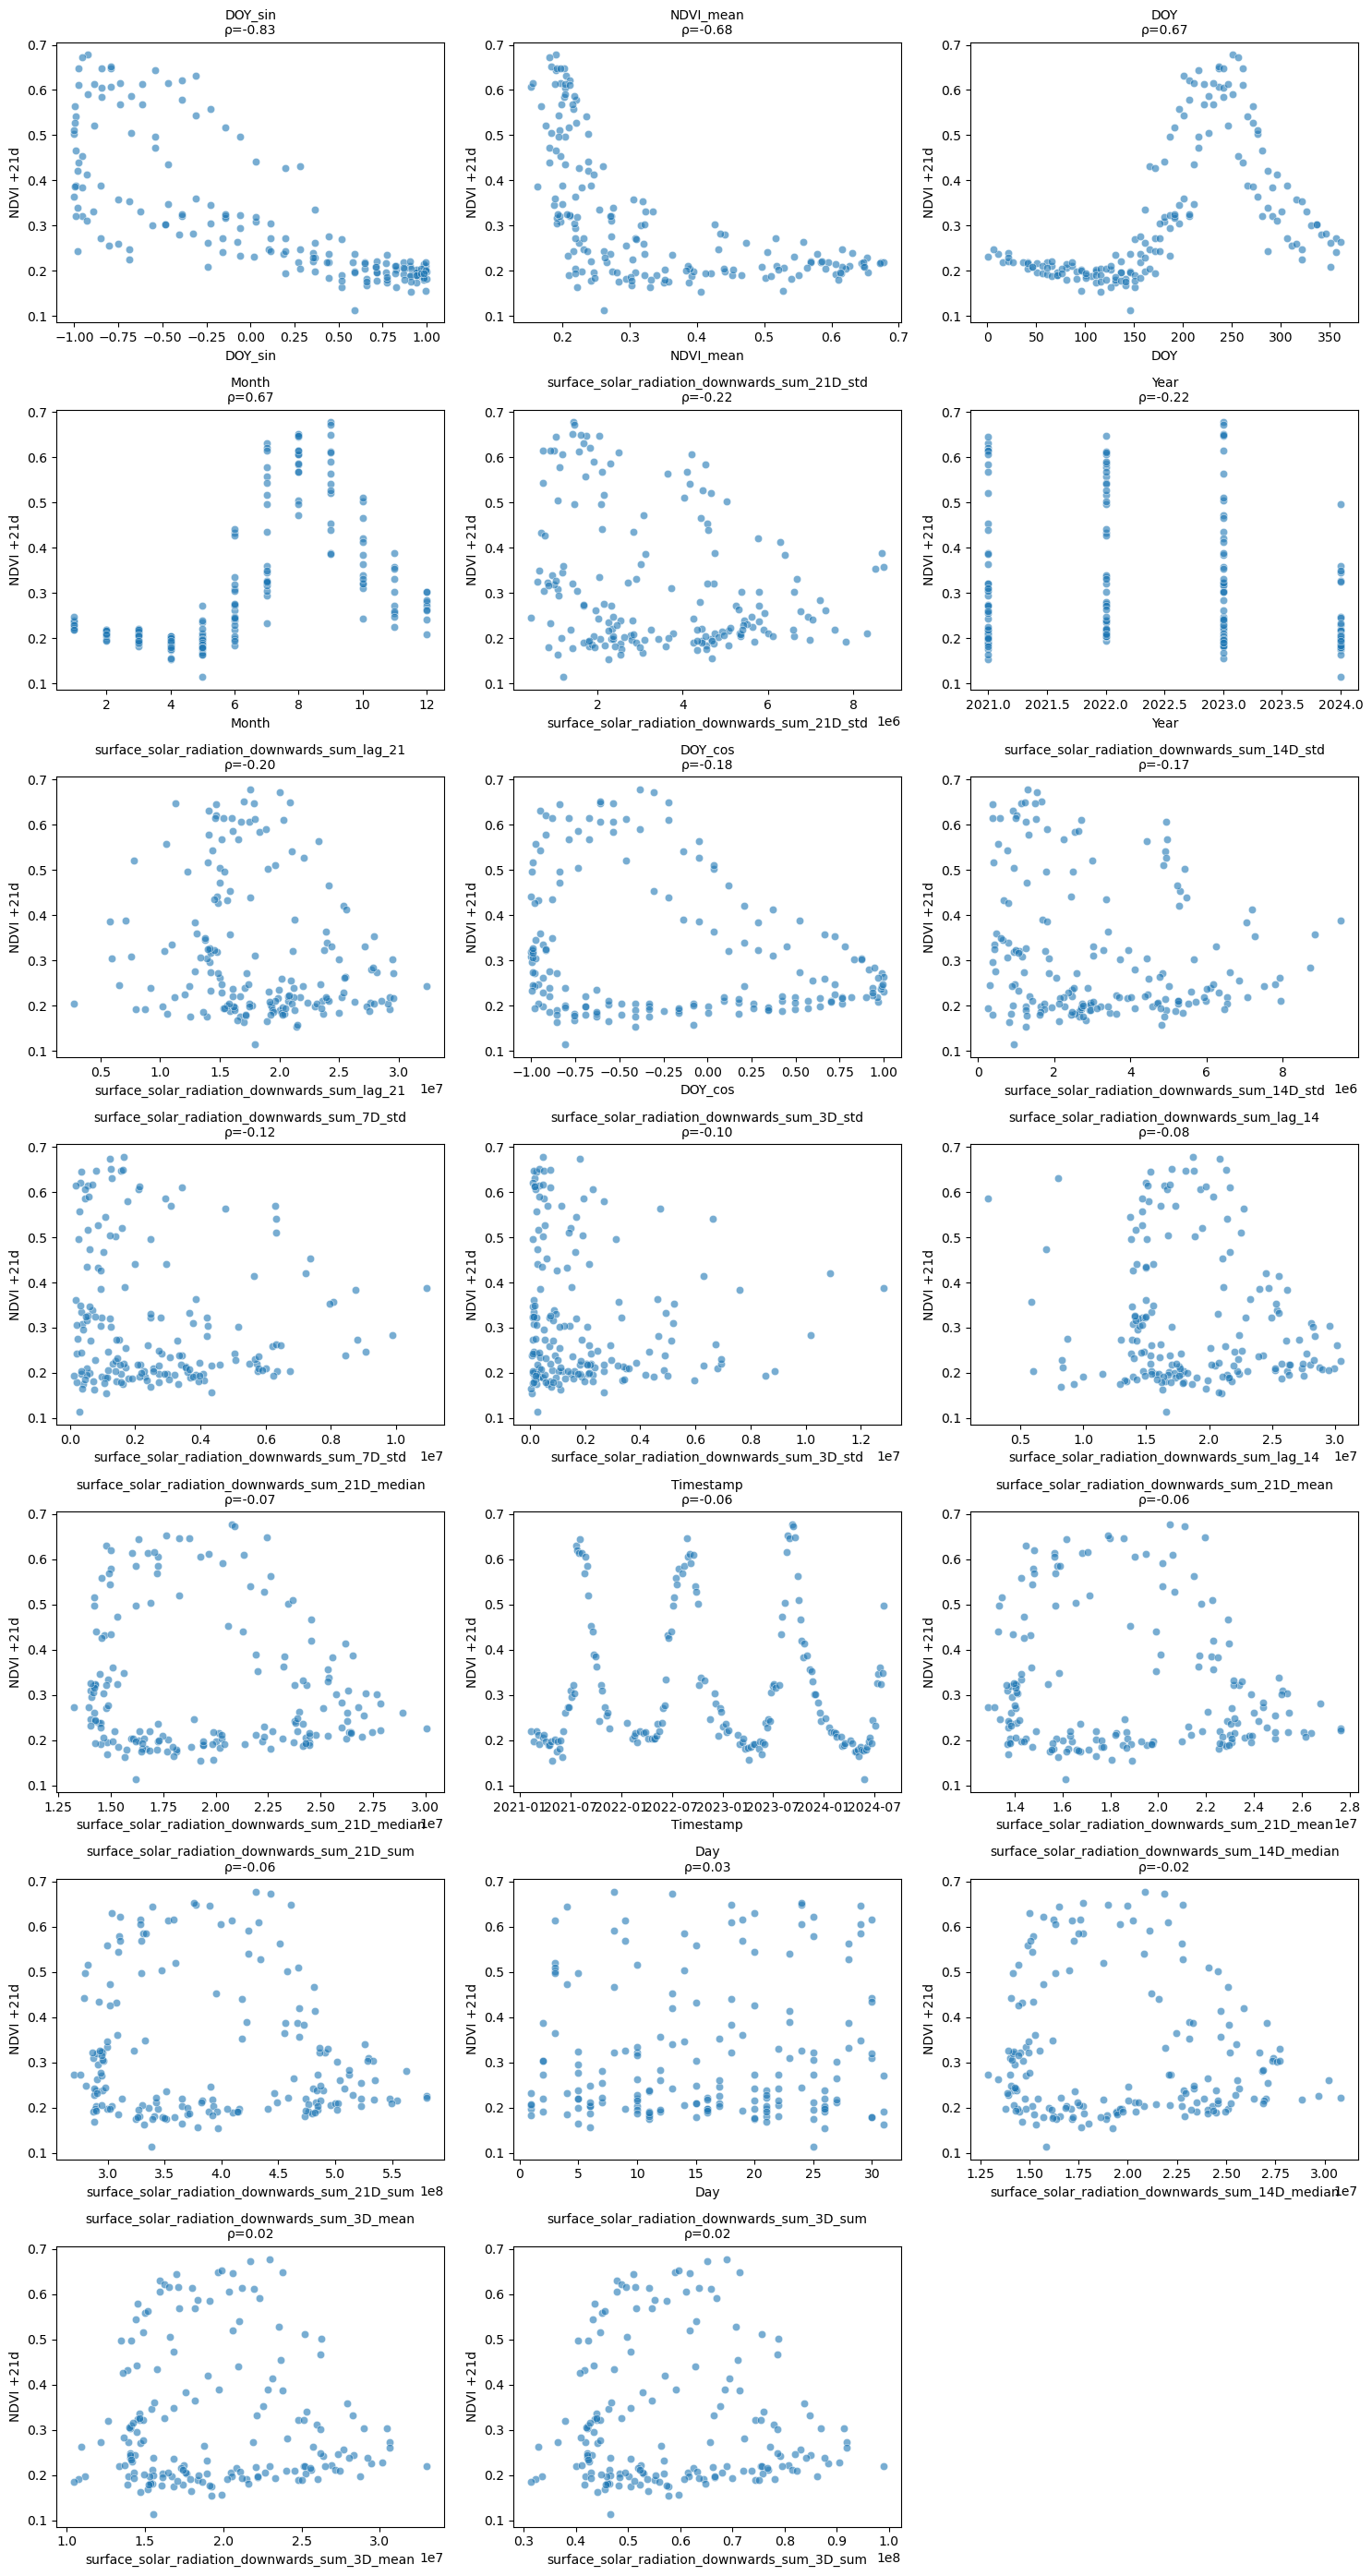

In [290]:
n = len(top_features)
cols = 3
rows = -(-n // cols)  # ceiling division

plt.figure(figsize=(5 * cols, 4 * rows))

for i, feature in enumerate(top_features):
    plt.subplot(rows, cols, i + 1)
    sns.scatterplot(x=df[feature], y=df['NDVI_target'], alpha=0.6)
    plt.title(f"{feature}\nρ={corrs[feature]:.2f}", fontsize=10)
    plt.xlabel(feature)
    plt.ylabel("NDVI +21d")

plt.tight_layout()
plt.show()

## Dates and Seasons

Since calender dates are cyclical, we will transform the timestamps using $\sin$ and $\cos$ in order to preserve this relationship for Machine Learning models.

Additionally, it might be a smart idea to have integers indicating day, month and year, as well as the day of year (DOY), in separate columns.

In [234]:
feature_df = utils.add_date_info(feature_df)
grouped_spectral_df = utils.add_date_info(grouped_spectral_df)
non_spectral_df = utils.add_date_info(non_spectral_df)

# Example:
feature_df.head()

,Timestamp,NDVI_mean,NDVI_target,Year,Month,Day,DOY,DOY_sin,DOY_cos
0,2021-02-10,0.673053,0.219043,2021,2,10,41,0.648262,0.761418
1,2021-02-20,0.654526,0.197174,2021,2,20,51,0.769031,0.639212
2,2021-03-02,0.594535,0.219492,2021,3,2,61,0.867099,0.498137
3,2021-03-07,0.626770,0.211328,2021,3,7,66,0.906686,0.421806
4,2021-03-12,0.550777,0.191533,2021,3,12,71,0.939570,0.342357


In [235]:
feature_df = engineering.sin_cos_doy(feature_df)
grouped_spectral_df = engineering.sin_cos_doy(grouped_spectral_df)
non_spectral_df = engineering.sin_cos_doy(non_spectral_df)

#Example
feature_df.head()

,Timestamp,NDVI_mean,NDVI_target,Year,Month,Day,DOY,DOY_sin,DOY_cos
0,2021-02-10,0.673053,0.219043,2021,2,10,41,0.648262,0.761418
1,2021-02-20,0.654526,0.197174,2021,2,20,51,0.769031,0.639212
2,2021-03-02,0.594535,0.219492,2021,3,2,61,0.867099,0.498137
3,2021-03-07,0.626770,0.211328,2021,3,7,66,0.906686,0.421806
4,2021-03-12,0.550777,0.191533,2021,3,12,71,0.939570,0.342357
